# STEP 1
- import & Clean DATA
- learning about the data

In [1]:
import sys
import pandas as pd
import numpy as np
print( f"Python {sys.version}\nPandas {pd.__version__}\nNumPy {np.__version__}\n" ) 

Python 3.10.4 (main, Jan 25 2023, 00:13:50) [GCC 9.4.0]
Pandas 1.5.3
NumPy 1.24.1



In [2]:
df_w = pd.read_csv('https://raw.githubusercontent.com/HikariJadeEmpire/TH_WLRD_Happiness_Project/main/DataForTable2')  
df_w_overall = pd.read_csv('https://raw.githubusercontent.com/HikariJadeEmpire/TH_WLRD_Happiness_Project/main/Appendix_2_Data_for_Figure_2')

df_w.info(); print('\n') # we will use this to be the main file
#df_w_overall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country name                       2089 non-null   object 
 1   year                               2089 non-null   int64  
 2   Life Ladder                        2089 non-null   float64
 3   Log GDP per capita                 2062 non-null   float64
 4   Social support                     2076 non-null   float64
 5   Healthy life expectancy at birth   2031 non-null   float64
 6   Freedom to make life choices       2057 non-null   float64
 7   Generosity                         2009 non-null   float64
 8   Perceptions of corruption          1976 non-null   float64
 9   Positive affect                    2065 non-null   float64
 10  Negative affect                    2073 non-null   float64
 11  Confidence in national government  1873 non-null   float

In [3]:
# Clean Column name to avoid error (eg.remove 'space')

df = df_w.loc[:]
df.rename(columns={'Country name':'country_name',
'Life Ladder':'life_lad','Log GDP per capita':'gdp_per_cap',
'Social support':'social_sup','Healthy life expectancy at birth':'health',
'Freedom to make life choices':'life_choice','Generosity':'generosity',
'Perceptions of corruption':'corruption','Positive affect':'pos_aff','Negative affect':'neg_aff',
'Confidence in national government':'conf_in_gov'},inplace=True)

# get results
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  2089 non-null   object 
 1   year          2089 non-null   int64  
 2   life_lad      2089 non-null   float64
 3   gdp_per_cap   2062 non-null   float64
 4   social_sup    2076 non-null   float64
 5   health        2031 non-null   float64
 6   life_choice   2057 non-null   float64
 7   generosity    2009 non-null   float64
 8   corruption    1976 non-null   float64
 9   pos_aff       2065 non-null   float64
 10  neg_aff       2073 non-null   float64
 11  conf_in_gov   1873 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 196.0+ KB


In [4]:
# Replace NaN by median respect to country

for i,name in enumerate(list(df)):
    if i > 2 :
        df[name].fillna(df.groupby(['country_name'])[name].transform('median'),inplace=True)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  2089 non-null   object 
 1   year          2089 non-null   int64  
 2   life_lad      2089 non-null   float64
 3   gdp_per_cap   2073 non-null   float64
 4   social_sup    2088 non-null   float64
 5   health        2051 non-null   float64
 6   life_choice   2089 non-null   float64
 7   generosity    2073 non-null   float64
 8   corruption    2060 non-null   float64
 9   pos_aff       2087 non-null   float64
 10  neg_aff       2088 non-null   float64
 11  conf_in_gov   1992 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 196.0+ KB


Look like some of them are still NaN.<br>
We've got to see what happened.

In [5]:
see=df.loc[ df['gdp_per_cap'].isna() | df['social_sup'].isna() | df['health'].isna() | df['generosity'].isna() 
           | df['corruption'].isna() | df['conf_in_gov'].isna() | df['neg_aff'].isna() , : ].groupby(by=['country_name'])

print(f"\n {'-'*4} List of countries that have NaN {'-'*4} \n")
for i in (see.groups) :
    print(i)

see1 = df.loc[df['country_name'].isin(['China']) ,:].reset_index(drop=True)
see2 = df.loc[df['country_name'].isin(['Hong Kong S.A.R. of China']) ,:].reset_index(drop=True)

display(see1)
display(see2)


 ---- List of countries that have NaN ---- 

Algeria
Bahrain
China
Cuba
Hong Kong S.A.R. of China
Kosovo
Libya
Maldives
North Cyprus
Oman
Saudi Arabia
Somaliland region
South Sudan
Sudan
Syria
Turkmenistan
United Arab Emirates


,country_name,year,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
0,China,2006,4.560495,8.696139,0.747011,65.660004,0.853072,-0.173937,NaN,0.657659,0.169580,NaN
1,China,2007,4.862862,8.823968,0.810852,65.919998,0.853072,-0.176961,NaN,0.663977,0.158614,NaN
2,China,2008,4.846295,8.910974,0.748287,66.180000,0.853072,-0.093270,NaN,0.705133,0.146963,NaN
3,China,2009,4.454361,8.995829,0.798034,66.440002,0.771143,-0.161358,NaN,0.669666,0.161650,NaN
4,China,2010,4.652737,9.092073,0.767753,66.699997,0.804794,-0.134285,NaN,0.658101,0.158100,NaN
5,China,2011,5.037208,9.177827,0.787171,66.959999,0.824162,-0.187382,NaN,0.710055,0.133503,NaN
6,China,2012,5.094917,9.246742,0.787818,67.220001,0.808255,-0.185606,NaN,0.689160,0.158703,NaN
7,China,2013,5.241090,9.314875,0.777896,67.480003,0.804724,-0.158647,NaN,0.717136,0.142211,NaN
8,China,2014,5.195619,9.380201,0.820366,67.739998,0.853072,-0.217615,NaN,0.709763,0.111518,NaN
9,China,2015,5.303878,9.442431,0.793734,68.000000,0.853072,-0.245284,NaN,0.666827,0.171315,NaN


,country_name,year,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
0,Hong Kong S.A.R. of China,2006,5.511187,10.746424,0.812178,NaN,0.909820,0.153046,0.355985,0.591140,0.235955,0.663938
1,Hong Kong S.A.R. of China,2008,5.137262,10.815546,0.840222,NaN,0.922211,0.293682,0.273945,0.575073,0.236634,0.677437
2,Hong Kong S.A.R. of China,2009,5.397056,10.788493,0.834716,NaN,0.918026,0.305077,0.272125,0.606459,0.210104,0.619142
3,Hong Kong S.A.R. of China,2010,5.642835,10.846634,0.857314,NaN,0.890418,0.329340,0.255775,0.600561,0.183106,0.634737
4,Hong Kong S.A.R. of China,2011,5.474011,10.886932,0.846060,NaN,0.894330,0.231902,0.244887,0.582491,0.195712,0.584562
5,Hong Kong S.A.R. of China,2012,5.483765,10.892753,0.826426,NaN,0.879752,0.219744,0.379783,0.580223,0.183349,0.497906
6,Hong Kong S.A.R. of China,2014,5.458051,10.939503,0.833558,NaN,0.843082,0.221097,0.422960,0.602495,0.242868,0.457823
7,Hong Kong S.A.R. of China,2016,5.498421,10.969857,0.832078,NaN,0.799743,0.097504,0.402813,0.568555,0.213115,0.449610
8,Hong Kong S.A.R. of China,2017,5.362475,10.999584,0.831066,NaN,0.830657,0.137305,0.415810,0.535812,0.200593,0.545041
9,Hong Kong S.A.R. of China,2019,5.659317,10.995179,0.855826,NaN,0.726852,0.064956,0.431974,0.519312,0.357607,0.332540


Here is the list of countries that still have NaN.<br> 
They have it because they hadn't had any records before<br>
so we can't calculate median from NaN and fill them<br>
We will consider dropping a country that is not in our interest and keeping the interesting one.<br>
Else, we just have to keep them.


Now we decided to keep them <br>
It's time to learn the features of DATA<br>

In [6]:
# Prepare data, sort by the best mean of life_lad

winner_df = df.groupby(['country_name']).apply(lambda x : x[['life_lad','gdp_per_cap','social_sup',
    'health','life_choice','generosity','corruption','pos_aff',
    'neg_aff','conf_in_gov']].mean()).sort_values(by=['life_lad'],ascending=False).reset_index()

display(winner_df)


,country_name,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
0,Denmark,7.681457,10.885137,0.956441,70.031562,0.944400,0.165070,0.198672,0.783656,0.197597,0.578037
1,Finland,7.611299,10.753935,0.950494,70.325358,0.941380,-0.001996,0.244848,0.738809,0.185581,0.596645
2,Switzerland,7.528177,11.127461,0.942772,71.978181,0.923328,0.094757,0.304179,0.756787,0.189489,0.770718
3,Norway,7.498840,11.059574,0.950138,70.931818,0.952737,0.135409,0.336738,0.786417,0.201050,0.675312
4,Iceland,7.459697,10.878041,0.977832,71.816666,0.930586,0.255945,0.696809,0.810800,0.162326,0.428385
...,...,...,...,...,...,...,...,...,...,...,...
161,Togo,3.603208,7.538181,0.470834,54.076000,0.622879,-0.041133,0.799416,0.564185,0.419719,0.424578
162,Burundi,3.548124,6.722510,0.417652,52.008000,0.451014,-0.035402,0.732270,0.570199,0.244124,0.736995
163,Central African Republic,3.514954,6.960999,0.402559,43.374000,0.680430,0.027961,0.842129,0.539942,0.391497,0.711735
164,Afghanistan,3.505506,7.586585,0.504086,52.353846,0.508496,0.077007,0.851207,0.450821,0.348225,0.382015


In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print( f"Matplotlib {mpl.__version__}" )

Matplotlib 3.6.3


To define what the Happiest countries look like, we join the 'happiness score' column from 'df_w_overall' file <br>
then sort the first 10th countries and define what the Happiest country looks like

,country,happiness_score,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
0,Finland,2.017205,2.000682,1.174286,1.216943,1.009667,1.640084,-0.055600,-2.757955,0.870574,-1.216741,0.622648
1,Denmark,1.843931,2.069567,1.296259,1.271757,0.962683,1.667049,1.062924,-3.013059,1.336497,-1.043420,0.515464
2,Iceland,1.769939,1.851831,1.289662,1.468914,1.248158,1.543696,1.671340,-0.261043,1.618500,-1.552148,-0.346566
3,Switzerland,1.727792,1.919069,1.521539,1.145768,1.273988,1.478883,0.592171,-2.430172,1.057350,-1.160367,1.625346
4,Netherlands,1.636940,1.848348,1.297202,1.051417,1.133282,1.307174,1.792635,-1.825293,0.811248,-0.833628,0.661452
5,Sweden,1.607905,1.767578,1.226673,1.010452,1.189371,1.547861,0.950446,-2.686737,1.115371,-1.281992,0.418301
6,Norway,1.590110,1.890263,1.458427,1.213663,1.106653,1.741495,0.864338,-2.250295,1.365181,-0.993622,1.075787
7,Israel,1.589173,1.636961,0.937150,0.790804,1.240995,-0.253296,0.724502,0.477992,-0.407837,0.481706,-0.623085
8,New Zealand,1.435569,1.693785,1.037148,1.237021,0.950119,1.469413,1.635329,-2.645347,1.351386,-1.005250,0.688325
9,Austria,1.400914,1.626904,1.293598,0.980503,1.016178,1.254877,0.831957,-0.987945,0.633124,-1.239091,-0.176797


/home/codespace/.local/lib/python3.10/site-packages/seaborn/axisgrid.py:712: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


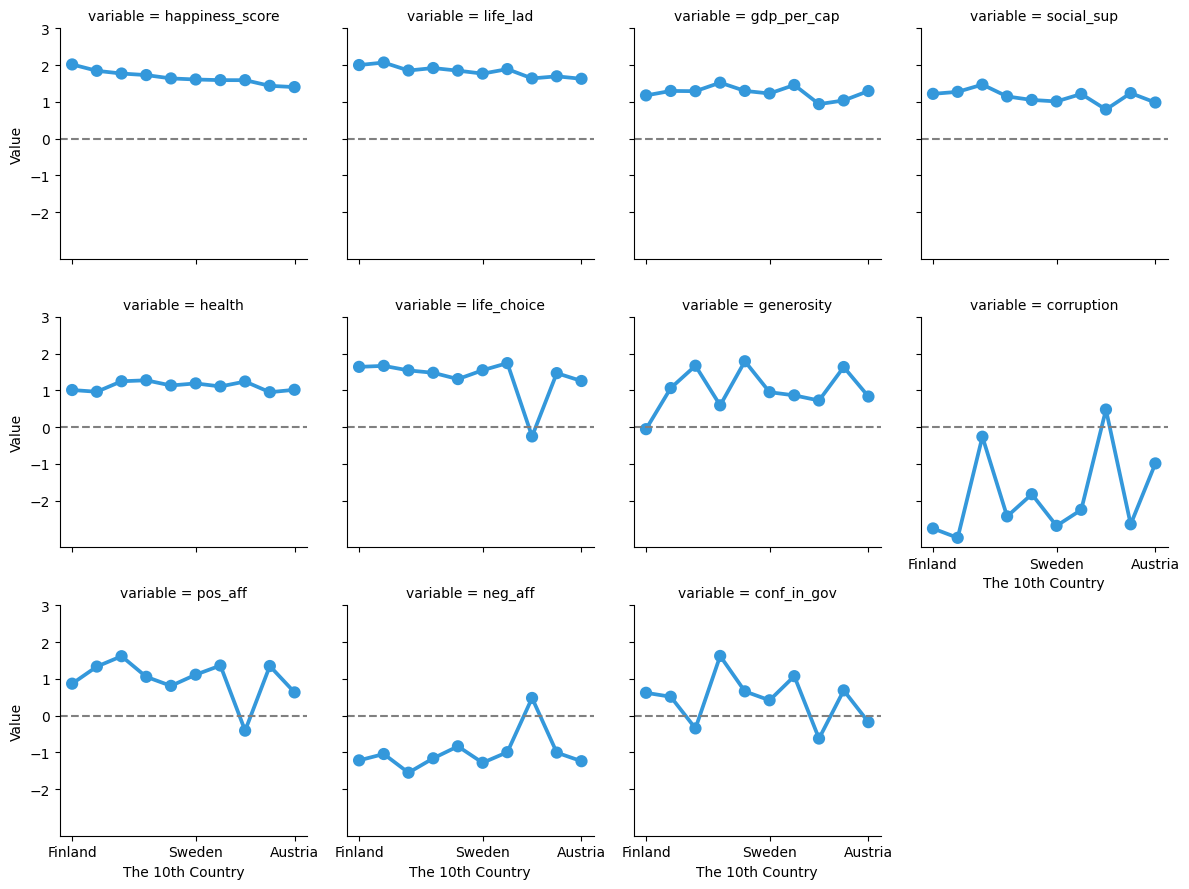

In [8]:
df_w_overall.rename(columns={'Happiness score':'happiness_score'},inplace=True)
wh = pd.merge(df_w_overall[['Country','happiness_score']],winner_df,left_on='Country',right_on='country_name',how='left')

st_wh = wh.loc[wh['country_name'].notna(),:].rename(columns={'Country':'country'}).drop(columns=['country_name']).reset_index(drop=True)

# Standardization

st_wh.iloc[:,1:] = st_wh.iloc[:,1:].apply(lambda x: (x-x.mean())/x.std() )
define = st_wh.iloc[:10]
display(define)

# set column to plotting easier

df_for_plot = define.melt(id_vars=['country'],value_vars=['happiness_score','life_lad','gdp_per_cap','social_sup',
    'health','life_choice','generosity','corruption','pos_aff',
    'neg_aff','conf_in_gov'])

# Plot

g = sns.FacetGrid(df_for_plot, col='variable' ,col_wrap=4 )
g.map(sns.pointplot, "country","value" ,color='#3498DB')
g.set_axis_labels("The 10th Country", "Value")
g.set(xticks=[0,5,9], yticks=[-2,-1,0,1,2,3])
g.refline(y=0)

# Now we have features of the first 10th of happiest countries
By standardization, the range of value will not swing too much.
- the reference line at zero means they are above or below the world mean
- This feature will be helpful when we compare it to other countries

# But our question is " What the most happiness country looks like ? "
- it seems like this feature still cannot answer that clearly.
- so, we decide to use another tool

[Text(70.58159722222221, 0.5, 'Variables')]

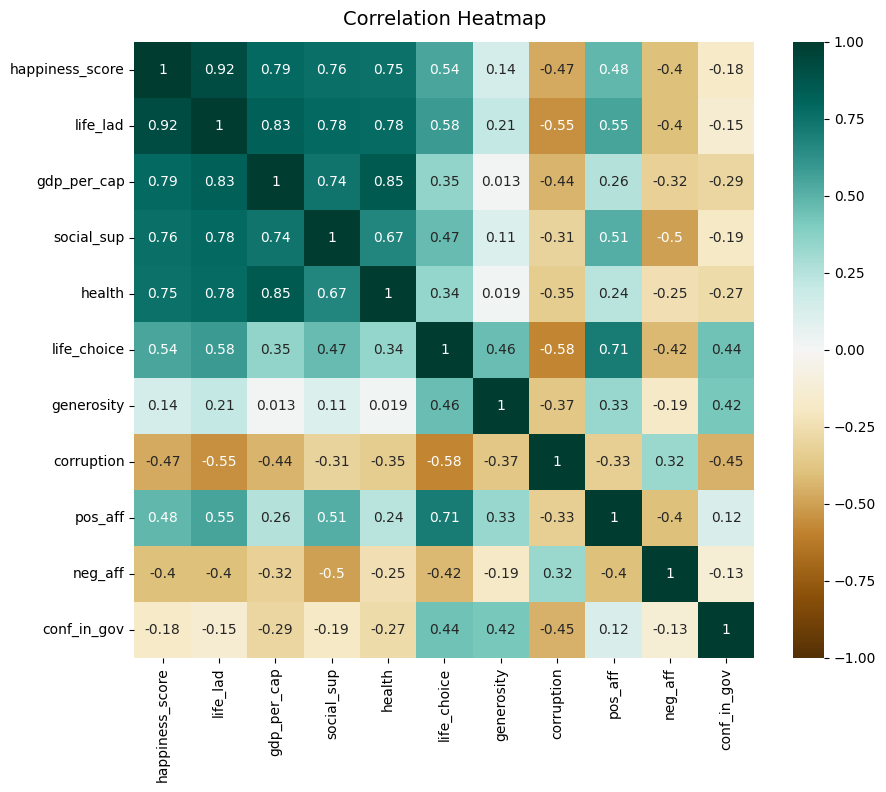

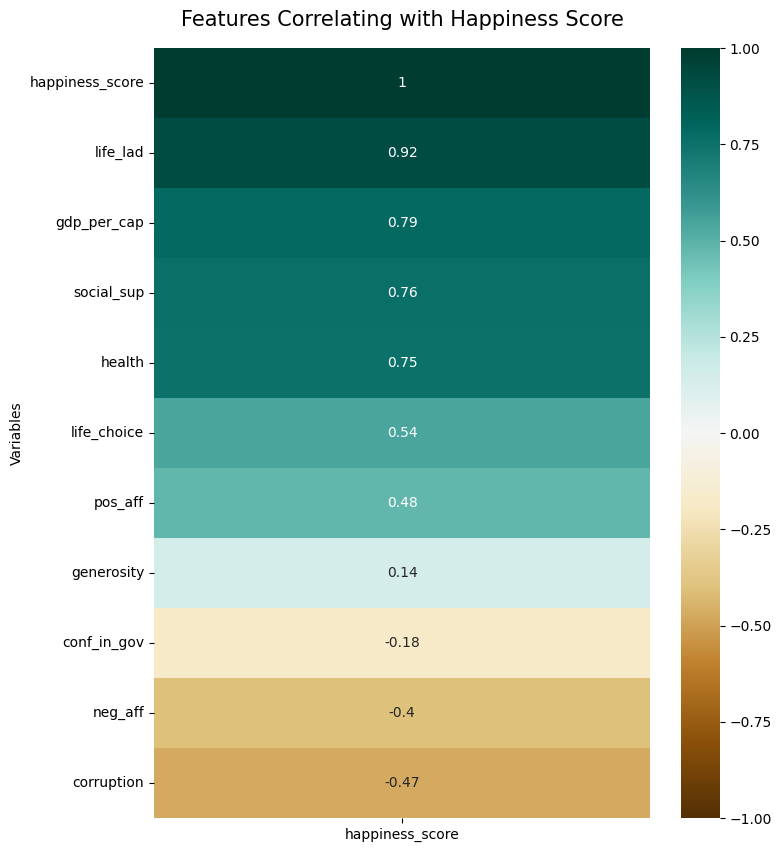

In [9]:
# Prepare DATA

nm_wh = wh.loc[wh['country_name'].notna(),:].rename(columns={'Country':'country'}).drop(columns=['country_name']).reset_index( drop=True )

# To clarify the previous plot, we will use a correlation tool to find out which variables support the happiness score

n_wh = nm_wh.iloc[:,1:]

# Increase the size of the heatmap.
plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(n_wh.corr(), dtype=np.bool_))
heatmap = sns.heatmap(n_wh.corr(), vmin=-1, vmax=1, annot=True , cmap='BrBG')
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12)

plt.figure(figsize=(8, 10))
heatmap = sns.heatmap(n_wh.corr()[['happiness_score']].sort_values(by='happiness_score', ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Features Correlating with Happiness Score', fontdict={'fontsize':15}, pad=16)
heatmap.set( ylabel='Variables')

# We can now say what the Happiest country should be by the graph
- Next step we will look at our country

In [10]:
# Find our country

display(st_wh.loc[st_wh['country']=='Thailand',:])
print(f"Thailand's ranking is {58} from {st_wh['country'].count()}\n\n ")

display(st_wh.iloc[:58,:])

,country,happiness_score,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
57,Thailand,0.209544,0.476865,0.152009,0.654954,0.572576,1.044467,2.466285,0.925048,1.371202,-1.140029,0.282543


Thailand's ranking is 58 from 124

 


,country,happiness_score,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
0,Finland,2.017205,2.000682,1.174286,1.216943,1.009667,1.640084,-0.055600,-2.757955,0.870574,-1.216741,0.622648
1,Denmark,1.843931,2.069567,1.296259,1.271757,0.962683,1.667049,1.062924,-3.013059,1.336497,-1.043420,0.515464
2,Iceland,1.769939,1.851831,1.289662,1.468914,1.248158,1.543696,1.671340,-0.261043,1.618500,-1.552148,-0.346566
3,Switzerland,1.727792,1.919069,1.521539,1.145768,1.273988,1.478883,0.592171,-2.430172,1.057350,-1.160367,1.625346
4,Netherlands,1.636940,1.848348,1.297202,1.051417,1.133282,1.307174,1.792635,-1.825293,0.811248,-0.833628,0.661452
5,Sweden,1.607905,1.767578,1.226673,1.010452,1.189371,1.547861,0.950446,-2.686737,1.115371,-1.281992,0.418301
6,Norway,1.590110,1.890263,1.458427,1.213663,1.106653,1.741495,0.864338,-2.250295,1.365181,-0.993622,1.075787
7,Israel,1.589173,1.636961,0.937150,0.790804,1.240995,-0.253296,0.724502,0.477992,-0.407837,0.481706,-0.623085
8,New Zealand,1.435569,1.693785,1.037148,1.237021,0.950119,1.469413,1.635329,-2.645347,1.351386,-1.005250,0.688325
9,Austria,1.400914,1.626904,1.293598,0.980503,1.016178,1.254877,0.831957,-0.987945,0.633124,-1.239091,-0.176797


/tmp/ipykernel_1190/1689200153.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')
/tmp/ipykernel_1190/1689200153.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inter_df['year'] = inter_df['year'].apply(lambda x : str(x))




------ we will compare 'Thailand ( our country )' vs 'Finland ( The Happiest country in the world )' ------

 


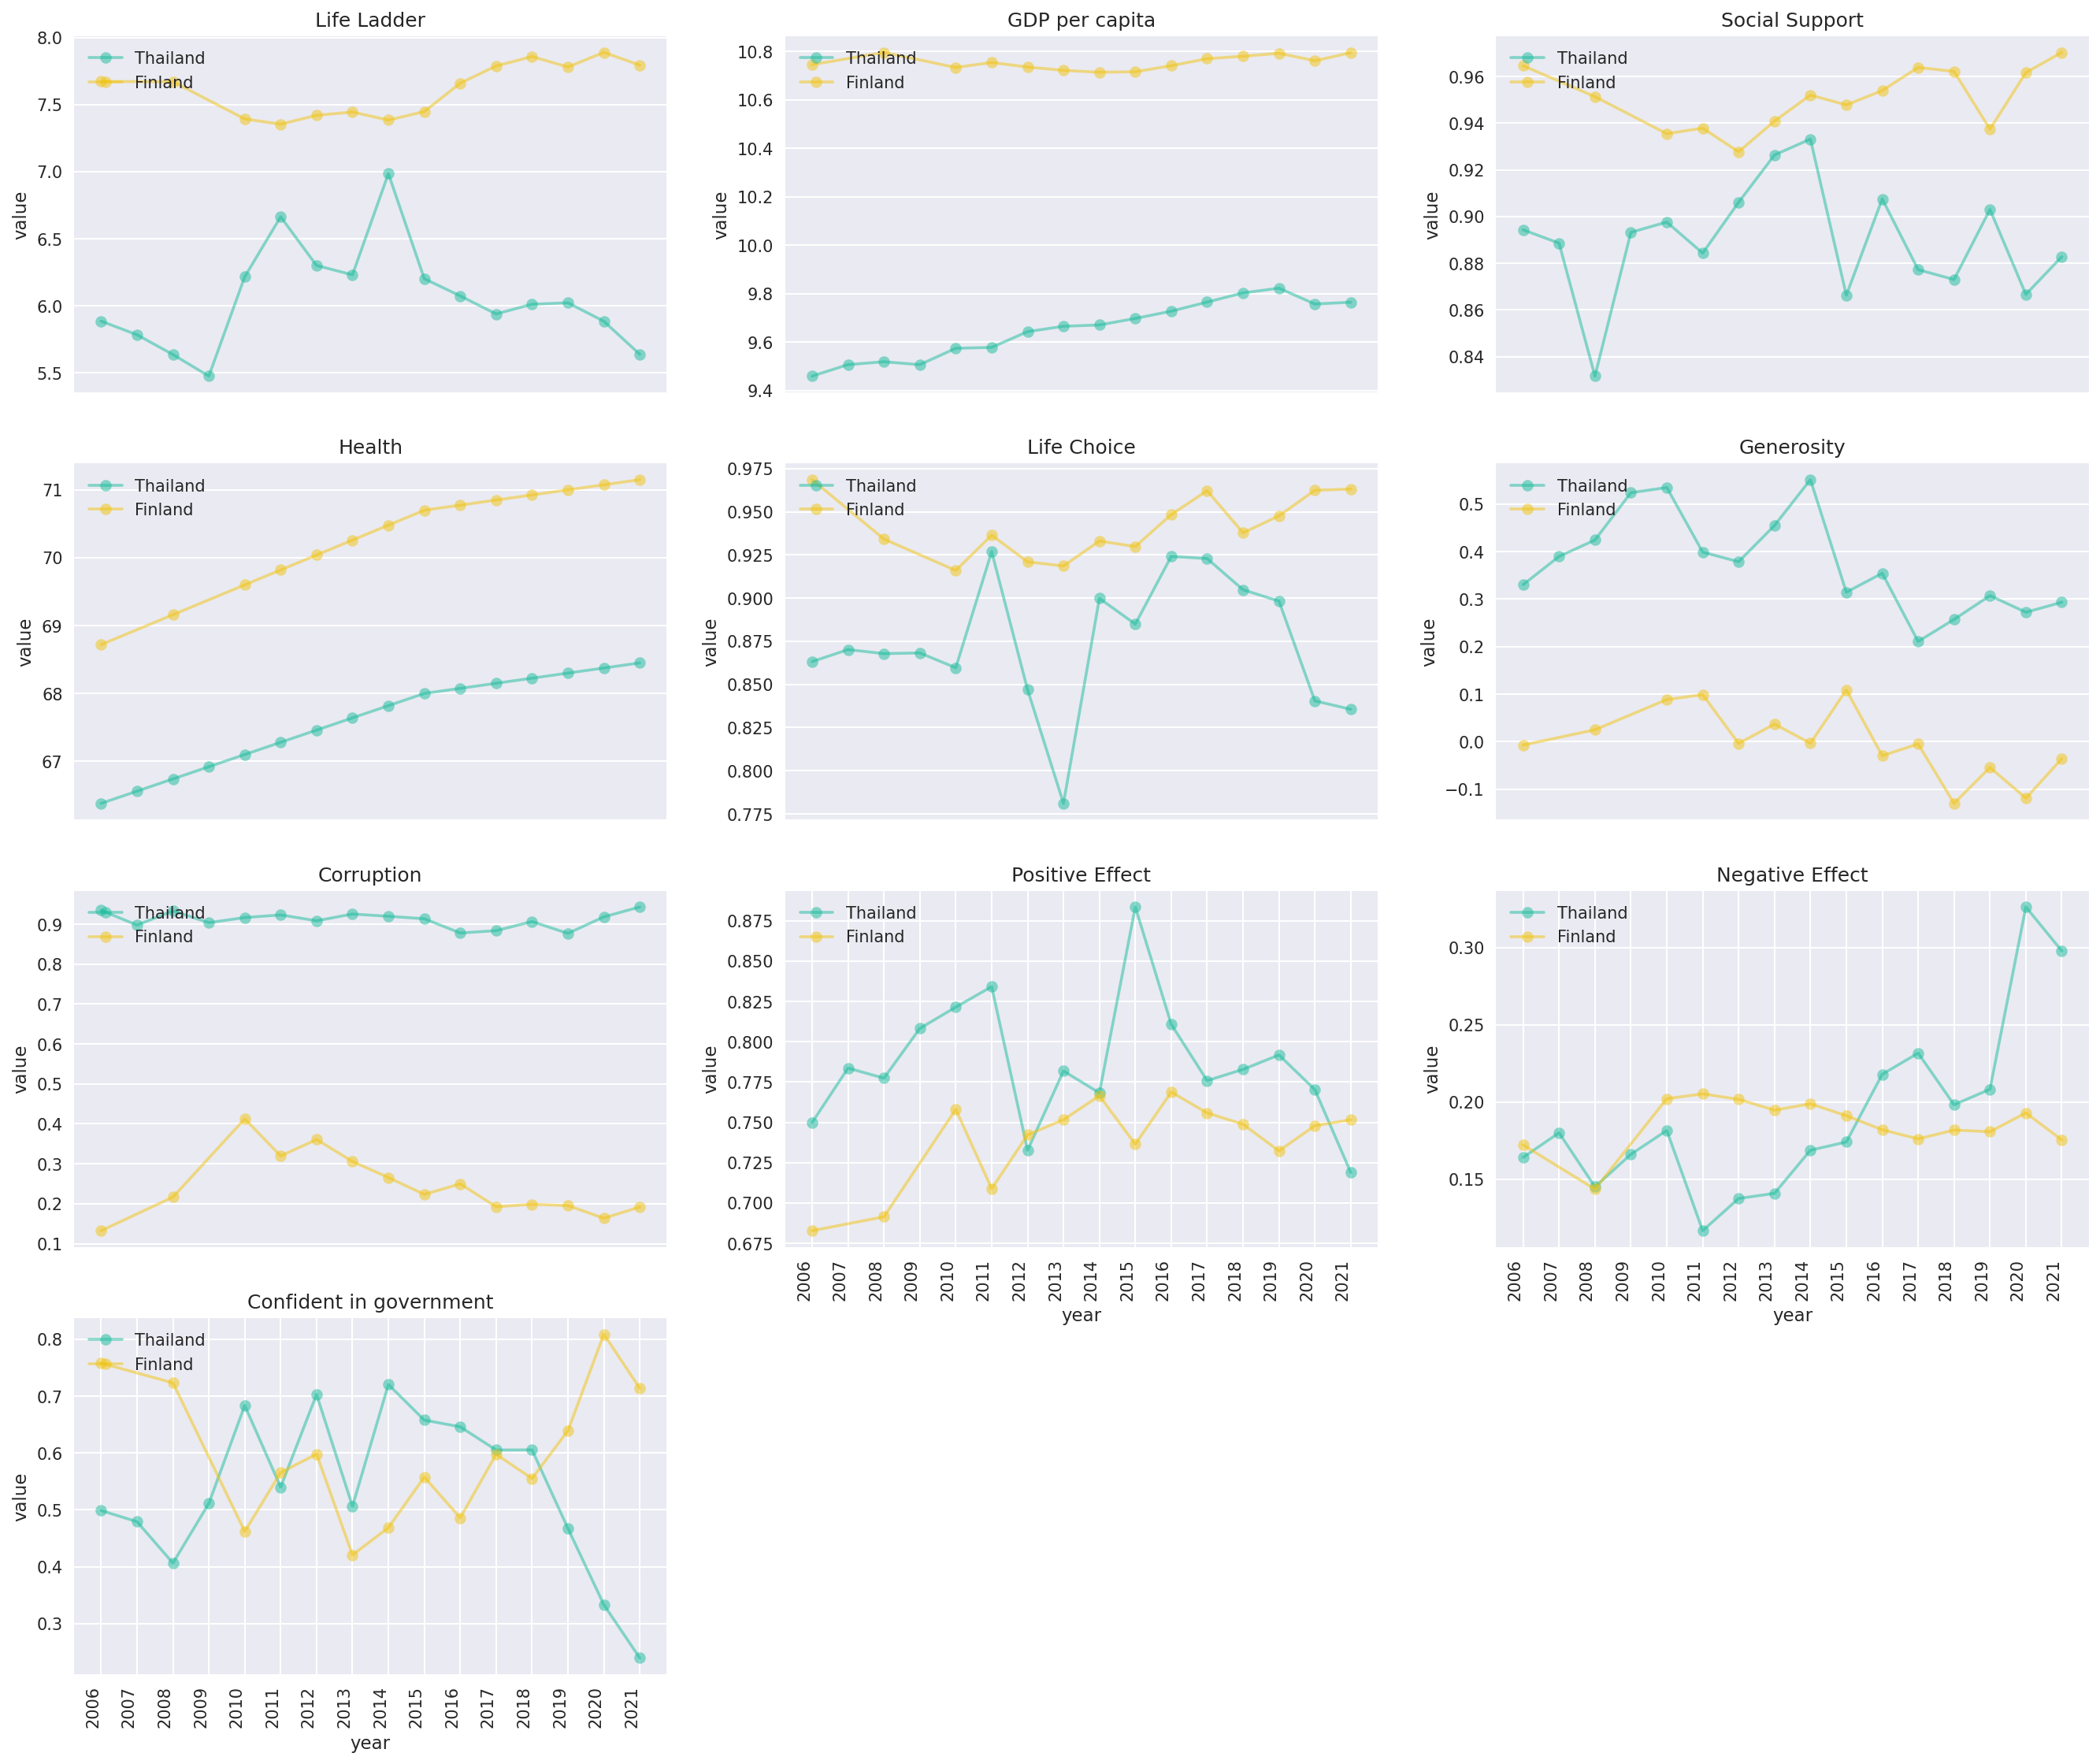

In [83]:
plt.style.use('seaborn')

# Scope our interest

interest = ['Finland','Denmark','Iceland','Switzerland','Netherlands','Sweden','Thailand']


inter_df = df.loc[df['country_name'].isin(interest),:]
inter_df['year'] = inter_df['year'].apply(lambda x : str(x))

th_hp = inter_df.loc[inter_df['country_name']=='Thailand', : ]
fn_hp = inter_df.loc[inter_df['country_name']=='Finland', : ]
print(f"\n\n{'-'*6} we will compare \'Thailand ( our country )\' vs \'Finland ( The Happiest country in the world )\' {'-'*6}\n\n ")

# PLOT

plt.figure(figsize=(22,18), dpi=150)

plt.subplot(4, 3, 1)
plt.plot(th_hp['year'], th_hp['life_lad'],color='#1ABC9C', marker='o', linestyle='solid', alpha=0.5 ,label="Thailand" )
plt.plot(fn_hp['year'], fn_hp['life_lad'],color='#F1C40F', marker='o', linestyle='solid', alpha=0.5 ,label="Finland" )
plt.title("Life Ladder");plt.xticks([]);plt.ylabel("value");plt.legend(loc="upper left")


plt.subplot(4, 3, 2)
plt.plot(th_hp['year'], th_hp['gdp_per_cap'],color='#1ABC9C', marker='o', linestyle='solid', alpha=0.5 ,label="Thailand" )
plt.plot(fn_hp['year'], fn_hp['gdp_per_cap'],color='#F1C40F', marker='o', linestyle='solid', alpha=0.5 ,label="Finland" )
plt.title("GDP per capita");plt.xticks([]);plt.ylabel("value");plt.legend(loc="upper left")


plt.subplot(4, 3, 3)
plt.plot(th_hp['year'], th_hp['social_sup'],color='#1ABC9C', marker='o', linestyle='solid', alpha=0.5 ,label="Thailand" )
plt.plot(fn_hp['year'], fn_hp['social_sup'],color='#F1C40F', marker='o', linestyle='solid', alpha=0.5 ,label="Finland" )
plt.title("Social Support");plt.xticks([]);plt.ylabel("value");plt.legend(loc="upper left")

plt.subplot(4, 3, 4)
plt.plot(th_hp['year'], th_hp['health'],color='#1ABC9C', marker='o', linestyle='solid', alpha=0.5 ,label="Thailand" )
plt.plot(fn_hp['year'], fn_hp['health'],color='#F1C40F', marker='o', linestyle='solid', alpha=0.5 ,label="Finland" )
plt.title("Health");plt.xticks([]);plt.ylabel("value");plt.legend(loc="upper left")

plt.subplot(4, 3, 5)
plt.plot(th_hp['year'], th_hp['life_choice'],color='#1ABC9C', marker='o', linestyle='solid', alpha=0.5 ,label="Thailand" )
plt.plot(fn_hp['year'], fn_hp['life_choice'],color='#F1C40F', marker='o', linestyle='solid', alpha=0.5 ,label="Finland" )
plt.title("Life Choice");plt.xticks([]);plt.ylabel("value");plt.legend(loc="upper left")

plt.subplot(4, 3, 6)
plt.plot(th_hp['year'], th_hp['generosity'],color='#1ABC9C', marker='o', linestyle='solid', alpha=0.5 ,label="Thailand" )
plt.plot(fn_hp['year'], fn_hp['generosity'],color='#F1C40F', marker='o', linestyle='solid', alpha=0.5 ,label="Finland" )
plt.title("Generosity");plt.xticks([]);plt.ylabel("value");plt.legend(loc="upper left")

plt.subplot(4, 3, 7)
plt.plot(th_hp['year'], th_hp['corruption'],color='#1ABC9C', marker='o', linestyle='solid', alpha=0.5 ,label="Thailand" )
plt.plot(fn_hp['year'], fn_hp['corruption'],color='#F1C40F', marker='o', linestyle='solid', alpha=0.5 ,label="Finland" )
plt.title("Corruption");plt.xticks([]);plt.ylabel("value");plt.legend(loc="upper left")

plt.subplot(4, 3, 8)
plt.plot(th_hp['year'], th_hp['pos_aff'],color='#1ABC9C', marker='o', linestyle='solid', alpha=0.5 ,label="Thailand" )
plt.plot(fn_hp['year'], fn_hp['pos_aff'],color='#F1C40F', marker='o', linestyle='solid', alpha=0.5 ,label="Finland" )
plt.xticks(rotation=90, ha='right')
plt.title("Positive Effect");plt.xlabel("year");plt.ylabel("value");plt.legend(loc="upper left")

plt.subplot(4, 3, 9)
plt.plot(th_hp['year'], th_hp['neg_aff'],color='#1ABC9C', marker='o', linestyle='solid', alpha=0.5 ,label="Thailand" )
plt.plot(fn_hp['year'], fn_hp['neg_aff'],color='#F1C40F', marker='o', linestyle='solid', alpha=0.5 ,label="Finland" )
plt.xticks(rotation=90, ha='right')
plt.title("Negative Effect");plt.xlabel("year");plt.ylabel("value");plt.legend(loc="upper left")

plt.subplot(4, 3, 10)
plt.plot(th_hp['year'], th_hp['conf_in_gov'],color='#1ABC9C', marker='o', linestyle='solid', alpha=0.5 ,label="Thailand" )
plt.plot(fn_hp['year'], fn_hp['conf_in_gov'],color='#F1C40F', marker='o', linestyle='solid', alpha=0.5 ,label="Finland" )
plt.xticks(rotation=90, ha='right')
plt.title("Confident in government");plt.xlabel("year");plt.ylabel("value");plt.legend(loc="upper left")